# Performance Benchmark Analysis — GPU / CPU / FPGA

Cross-platform comparison of **latency**, **throughput**, **power**, and **energy efficiency**
for the SAR DDC hyper-autoencoder across three backends:

| Backend | Hardware | Precision | Entropy Coding |
|---|---|---|---|
| **GPU** | NVIDIA RTX A4000 (16 GB) | FP32 | CompressAI Python (x86) |
| **CPU** | Host x86 (same machine) | FP32 | CompressAI Python (x86) |
| **FPGA** | Xilinx ZCU102 (DPU B4096) | INT8 | C++ rANS (`ans.so`, ARM A53) |

**Data sources:** JSON files produced by `benchmark_gpu.py` and `benchmark_fpga.py`
via the orchestrator `run_full_benchmark.py`.

**Structure:**
1. Setup & configuration
2. Load & merge all JSON results → unified DataFrame
3. Overview table
4. End-to-end latency comparison (bar chart)
5. Per-step latency breakdown (stacked bars)
6. NN vs entropy latency split
7. Throughput comparison
8. Power consumption
9. Energy per inference (the fairest cross-platform metric)
10. Summary table for publication

## 1 · Setup & Configuration

In [39]:
import json
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.axes import Axes
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT_DIR = Path("..").resolve()

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SET THIS to the model you want to analyse                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
BENCHMARK_DIR = ROOT_DIR / "results" / "benchmark" / "ResSHyp-relu_s1_L1000_pt"

assert BENCHMARK_DIR.exists(), f"Benchmark directory not found: {BENCHMARK_DIR}"
MODEL_NAME = BENCHMARK_DIR.name
print(f"Analysing: {MODEL_NAME}")
print(f"Directory: {BENCHMARK_DIR}")
print(f"JSON files found: {sorted(p.name for p in BENCHMARK_DIR.glob('*.json'))}")

# ── Plotting style ─────────────────────────────────────────────────────────────
PLATFORM_COLORS = {"gpu": "#1f77b4", "cpu": "#ff7f0e", "fpga": "#2ca02c"}
PLATFORM_LABELS = {"gpu": "GPU (RTX A4000)", "cpu": "CPU (x86 host)", "fpga": "FPGA (ZCU102)"}
PLATFORM_ORDER  = ["gpu", "cpu", "fpga"]

# Scenario display names & ordering
SCENARIO_ORDER = ["full", "compress", "decompress", "nn_only", "entropy_only"]
SCENARIO_LABELS = {
    "full": "Full\n(Enc+Dec)",
    "compress": "Compress\n(Encode)",
    "decompress": "Decompress\n(Decode)",
    "nn_only": "NN Only",
    "entropy_only": "Entropy\nOnly",
}

# Map equivalent scenarios across platforms for side-by-side comparisons.
# GPU/CPU call it "nn_only", FPGA calls it "dpu_only" — same conceptual scenario.
SCENARIO_MAP_TO_CANONICAL = {"dpu_only": "nn_only"}

SAVE_FIGURES = False
PLOTS_DIR = ROOT_DIR / "results" / "plots" / "benchmark"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

Analysing: ResSHyp-relu_s1_L1000_pt
Directory: /mnt/vitisAI/Vitis-AI/DDC_FPGA/results/benchmark/ResSHyp-relu_s1_L1000_pt
JSON files found: ['benchmark_cpu_compress.json', 'benchmark_cpu_decompress.json', 'benchmark_cpu_entropy_only.json', 'benchmark_cpu_full.json', 'benchmark_cpu_nn_only.json', 'benchmark_fpga_compress.json', 'benchmark_fpga_compress_sequential.json', 'benchmark_fpga_decompress.json', 'benchmark_fpga_decompress_sequential.json', 'benchmark_fpga_dpu_only.json', 'benchmark_fpga_dpu_only_sequential.json', 'benchmark_fpga_entropy_only.json', 'benchmark_fpga_entropy_only_sequential.json', 'benchmark_fpga_full.json', 'benchmark_fpga_full_sequential.json', 'benchmark_gpu_compress.json', 'benchmark_gpu_decompress.json', 'benchmark_gpu_entropy_only.json', 'benchmark_gpu_full.json', 'benchmark_gpu_nn_only.json']


## 2 · Load & Merge All JSON Results

Each JSON file is one `(platform, scenario)` measurement. File naming conventions:

| Pattern | Platform | Source script |
|---|---|---|
| `benchmark_gpu_<scenario>.json` | GPU (CUDA) | `benchmark_gpu.py` |
| `benchmark_cpu_<scenario>.json` | CPU (x86 host) | `benchmark_gpu.py --no-gpu` |
| `benchmark_fpga_<scenario>.json` | FPGA (ZCU102 DPU) | `benchmark_fpga.py` |

All three share the same top-level schema (see `performance_benchmark_implementation.md`
§5.5 and §9.8).  Key differences:

- **Step label prefixes**: `gpu_` (GPU NN), `nn_` (CPU NN), `dpu_` (FPGA NN),
  `cpu_` (entropy / data ops on all platforms).
- **Power keys**: GPU → `power.gpu` (nvidia-smi) + `power.cpu_rapl`;
  FPGA → `power.per_rail` (INA226) + `power.groups_avg_w`.
- **FPGA scenario name**: `dpu_only` ↔ `nn_only` on GPU/CPU (same concept,
  different label).

In [ ]:
def _classify_file(name: str) -> Tuple[str, str]:
    """Return (platform, scenario) from a benchmark JSON filename.

    Naming conventions:
      benchmark_gpu_<scenario>.json   → ("gpu",  scenario)
      benchmark_cpu_<scenario>.json   → ("cpu",  scenario)
      benchmark_fpga_<scenario>.json  → ("fpga", scenario)

    Legacy: ``benchmark_<scenario>.json`` (no platform tag) is treated as FPGA.
    Sequential FPGA files (``benchmark_fpga_<scenario>_sequential.json``) are
    identified here but filtered out in ``load_all_results`` — they are used
    exclusively in §11 (parallel vs sequential comparison).
    """
    stem = name.replace(".json", "")
    parts = stem.split("_")  # e.g. ["benchmark", "gpu", "full"]

    if len(parts) >= 3 and parts[1] in ("gpu", "cpu", "fpga"):
        platform = parts[1]
        scenario = "_".join(parts[2:])
    else:
        # Legacy FPGA: benchmark_<scenario>.json (no platform prefix)
        platform = "fpga"
        scenario = "_".join(parts[1:])

    # Canonicalise FPGA's "dpu_only" → "nn_only"
    scenario = SCENARIO_MAP_TO_CANONICAL.get(scenario, scenario)
    return platform, scenario


def _extract_power(data: dict, platform: str) -> Dict[str, Optional[float]]:
    """Extract power metrics into a flat dict, regardless of platform schema.

    Returns keys:
      power_total_w       — total measured power (W) during the workload
      power_nn_w          — power attributable to the NN accelerator domain
      power_cpu_w         — power attributable to the CPU / entropy domain
      power_idle_total_w  — idle baseline (if captured)
      energy_total_j      — total energy over the measurement window
    """
    pw = data.get("power", {})
    out: Dict[str, Optional[float]] = {
        "power_total_w": None,
        "power_nn_w": None,
        "power_cpu_w": None,
        "power_idle_total_w": None,
        "energy_total_j": None,
    }
    if not pw:
        return out

    if platform == "fpga":
        # FPGA: INA226 per-rail grouped by board_total / DPU_fabric / PS_compute
        groups = pw.get("groups_avg_w", {})
        out["power_total_w"] = pw.get("board_total_avg_w")
        out["power_nn_w"] = groups.get("DPU_fabric")
        out["power_cpu_w"] = groups.get("PS_compute")

        # Energy: board_total x duration
        duration = None
        for rail_data in pw.get("per_rail", {}).values():
            if isinstance(rail_data, dict) and "duration_s" in rail_data:
                duration = rail_data["duration_s"]
                break
        if out["power_total_w"] is not None and duration:
            out["energy_total_j"] = out["power_total_w"] * duration

        # Idle baseline
        # idle_board_total_avg_w is at the top level of power_data.
        # idle_baseline contains per-rail dicts (no board_total sub-key).
        idle = pw.get("idle_baseline", {})
        if idle:
            if pw.get("idle_board_total_avg_w") is not None:
                out["power_idle_total_w"] = pw.get("idle_board_total_avg_w")
            else:
                out["power_idle_total_w"] = sum(
                    v.get("avg_power_w", 0.0) for v in idle.values()
                    if isinstance(v, dict)
                )

    elif platform == "gpu":
        # GPU: nvidia-smi + RAPL (both measured simultaneously)
        gpu_pw = pw.get("gpu", {})
        rapl_total = pw.get("cpu_rapl_total_avg_w", 0.0)
        gpu_w = gpu_pw.get("avg_power_w", 0.0) if gpu_pw else 0.0

        out["power_nn_w"] = gpu_w
        out["power_cpu_w"] = rapl_total
        out["power_total_w"] = gpu_w + rapl_total

        # Energy: sum of individual energies
        gpu_e = gpu_pw.get("energy_j", 0.0) if gpu_pw else 0.0
        rapl_e = sum(
            v.get("energy_j", 0.0) for v in pw.get("cpu_rapl", {}).values()
            if isinstance(v, dict)
        )
        out["energy_total_j"] = gpu_e + rapl_e

        # Idle
        idle_gpu = pw.get("idle_gpu", {})
        idle_rapl = pw.get("idle_cpu_rapl", {})
        if idle_gpu or idle_rapl:
            idle_g = idle_gpu.get("avg_power_w", 0.0) if idle_gpu else 0.0
            idle_r = sum(
                v.get("avg_power_w", 0.0) for v in idle_rapl.values()
                if isinstance(v, dict)
            )
            out["power_idle_total_w"] = idle_g + idle_r

    elif platform == "cpu":
        # CPU-only: only RAPL
        rapl_total = pw.get("cpu_rapl_total_avg_w", 0.0)
        out["power_nn_w"] = None  # no dedicated accelerator
        out["power_cpu_w"] = rapl_total
        out["power_total_w"] = rapl_total

        rapl_e = sum(
            v.get("energy_j", 0.0) for v in pw.get("cpu_rapl", {}).values()
            if isinstance(v, dict)
        )
        out["energy_total_j"] = rapl_e

        idle_rapl = pw.get("idle_cpu_rapl", {})
        if idle_rapl:
            out["power_idle_total_w"] = sum(
                v.get("avg_power_w", 0.0) for v in idle_rapl.values()
                if isinstance(v, dict)
            )

    return out


def _extract_step_breakdown(data: dict, platform: str) -> Dict[str, float]:
    """Return {step_label: mean_ms} from the latency_breakdown, renaming prefixes
    to canonical 'nn_' and 'cpu_' for uniform cross-platform comparison.

    Original prefixes: gpu_ (GPU), nn_ (CPU-as-NN), dpu_ (FPGA).
    Canonical:         nn_ (NN accelerator), cpu_ (entropy/data ops).
    """
    breakdown = data.get("latency_breakdown", {})
    out: Dict[str, float] = {}
    for step, stats in breakdown.items():
        if not isinstance(stats, dict):
            continue
        mean_s = stats.get("mean_s", 0.0)
        # Rename platform-specific NN prefixes to canonical "nn_"
        canonical = step
        if platform == "gpu" and step.startswith("gpu_"):
            canonical = "nn_" + step[4:]
        elif platform == "fpga" and step.startswith("dpu_"):
            canonical = "nn_" + step[4:]
        out[canonical] = mean_s * 1000  # convert to ms
    return out


def load_all_results(benchmark_dir: Path) -> pd.DataFrame:
    """Load all benchmark_*.json files from a directory into a tidy DataFrame.

    One row per (platform, scenario).  Columns include latency, throughput,
    power, and per-step breakdown (as a nested dict for later expansion).

    Sequential FPGA files (``benchmark_fpga_<scenario>_sequential.json``) are
    excluded here and loaded directly in §11 (parallel vs sequential comparison).
    They are NOT included in the main ``df`` DataFrame used by §2–§10.
    """
    rows: List[Dict[str, Any]] = []
    skipped_seq: List[str] = []

    for jpath in sorted(benchmark_dir.glob("benchmark_*.json")):
        platform, scenario = _classify_file(jpath.name)
        # Sequential FPGA files are not part of the main analysis.
        # They are loaded directly from disk in §11.
        if scenario.endswith("_sequential"):
            skipped_seq.append(jpath.name)
            continue
        with open(jpath) as f:
            data: dict = json.load(f)

        # ── Core metrics ───────────────────────────────────────────────
        # Latency (ms)
        latency_ms = data.get("latency_total_mean_ms", 0.0)

        # NN vs CPU latency split — keys differ by platform
        nn_key = next(
            (k for k in data if k.startswith("latency_") and k.endswith("_total_mean_ms")
             and k not in ("latency_total_mean_ms", "latency_cpu_total_mean_ms")),
            None,
        )
        nn_latency_ms = data.get(nn_key, 0.0) if nn_key else 0.0
        cpu_latency_ms = data.get("latency_cpu_total_mean_ms", 0.0)

        # Throughput
        throughput_fps = data.get("throughput_fps", 0.0)

        # Compressed bytes → BPP
        avg_bytes = data.get("avg_compressed_bytes")
        bpp = (avg_bytes * 8 / (256 * 256)) if avg_bytes else None

        # Power
        power = _extract_power(data, platform)

        # Per-step breakdown (kept as dict — expanded in dedicated section)
        steps = _extract_step_breakdown(data, platform)

        # Energy per inference:  E_tile = P_total x t_tile
        energy_per_tile_mj = None
        if power["power_total_w"] is not None and latency_ms > 0:
            energy_per_tile_mj = power["power_total_w"] * (latency_ms / 1000) * 1000  # mJ

        row: Dict[str, Any] = {
            "platform": platform,
            "scenario": scenario,
            "source_file": jpath.name,
            # Latency
            "latency_ms": latency_ms,
            "nn_latency_ms": nn_latency_ms,
            "cpu_latency_ms": cpu_latency_ms,
            "nn_fraction": nn_latency_ms / latency_ms if latency_ms > 0 else 0,
            # Throughput
            "throughput_fps": throughput_fps,
            # Compression
            "avg_compressed_bytes": avg_bytes,
            "bpp": bpp,
            # Power
            **power,
            # Energy per tile
            "energy_per_tile_mj": energy_per_tile_mj,
            # Iterations
            "n_warmup": data.get("n_warmup"),
            "n_iters": data.get("n_iters"),
            # Breakdown (nested dict)
            "_step_breakdown": steps,
            # Raw data ref
            "_raw": data,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    # Ensure consistent ordering
    df["platform"] = pd.Categorical(df["platform"], categories=PLATFORM_ORDER, ordered=True)
    df = df.sort_values(["scenario", "platform"]).reset_index(drop=True)
    if skipped_seq:
        print(f"  → Skipped {len(skipped_seq)} sequential file(s) (§11 only): "
              + ", ".join(skipped_seq))
    return df


# ── Load ───────────────────────────────────────────────────────────────────────
df = load_all_results(BENCHMARK_DIR)

print(f"Loaded {len(df)} benchmark results:")
for _, row in df.iterrows():
    pw_str = f"  {row['power_total_w']:.1f} W" if row["power_total_w"] else "  no power"
    print(f"  {row['platform']:5s}  {row['scenario']:25s}  {row['latency_ms']:8.2f} ms{pw_str:9s}  ← {row['source_file']}")

# Check completeness
expected = {(p, s) for p in PLATFORM_ORDER for s in SCENARIO_ORDER}
actual = set(zip(df["platform"].astype(str), df["scenario"]))
missing = expected - actual
if missing:
    print(f"\n⚠  Missing {len(missing)} combinations:")
    for p, s in sorted(missing):
        print(f"    {p} / {s}")
else:
    print(f"\n✓ All {len(expected)} (platform x scenario) combinations present.")


Loaded 20 benchmark results:
  gpu    compress                      15.72 ms  140.1 W  ← benchmark_gpu_compress.json
  cpu    compress                     120.94 ms  101.6 W  ← benchmark_cpu_compress.json
  fpga   compress                     224.72 ms  10.6 W   ← benchmark_fpga_compress.json
  fpga   compress_sequential          261.20 ms  10.3 W   ← benchmark_fpga_compress_sequential.json
  gpu    decompress                    16.49 ms  132.7 W  ← benchmark_gpu_decompress.json
  cpu    decompress                   135.27 ms  100.6 W  ← benchmark_cpu_decompress.json
  fpga   decompress                   229.54 ms  10.2 W   ← benchmark_fpga_decompress.json
  fpga   decompress_sequential        248.45 ms  10.2 W   ← benchmark_fpga_decompress_sequential.json
  fpga   dpu_only_sequential          199.94 ms  11.6 W   ← benchmark_fpga_dpu_only_sequential.json
  gpu    entropy_only                  22.71 ms  121.4 W  ← benchmark_gpu_entropy_only.json
  cpu    entropy_only                  25

## 3 · Overview Table

A compact summary of every `(platform, scenario)` pair.  This is the single source
of truth for all plots below — scan it for anomalies (e.g. a scenario that returned
0 ms latency, or missing power data) before interpreting the charts.

**Reading guide:**
- **Latency** is the mean wall-clock time for one 256x256 patch across `n_iters` iterations,
  measured via `time.perf_counter()` with appropriate synchronisation
  (`torch.cuda.synchronize()` on GPU, blocking VART calls on FPGA).
- **NN / CPU split**: NN = sum of all `gpu_*` / `dpu_*` / `nn_*` steps; CPU = sum of all
  `cpu_*` steps (entropy coding + data manipulation).  The split may not exactly equal
  `latency_ms` due to pre/postprocess steps and rounding.
- **Throughput** = `n_iters / wall_total_s`.  Includes all Python overhead between iterations.
- **Power** columns may be empty if `--power` was not used or if RAPL was unavailable (see §1).

In [41]:
overview_cols = [
    "scenario", "platform",
    "latency_ms", "nn_latency_ms", "cpu_latency_ms",
    "throughput_fps",
    "power_total_w", "power_nn_w", "power_cpu_w",
    "energy_per_tile_mj",
    "bpp",
    "n_warmup", "n_iters",
]

overview = df[overview_cols].copy()
overview["platform"] = overview["platform"].map(PLATFORM_LABELS)
# Sort by scenario then platform
overview["scenario"] = pd.Categorical(overview["scenario"], categories=SCENARIO_ORDER, ordered=True)
overview = overview.sort_values(["scenario", "platform"]).reset_index(drop=True)

# Format for readability
fmt = {
    "latency_ms":        "{:.2f}",
    "nn_latency_ms":     "{:.2f}",
    "cpu_latency_ms":    "{:.2f}",
    "throughput_fps":    "{:.2f}",
    "power_total_w":     "{:.2f}",
    "power_nn_w":        "{:.2f}",
    "power_cpu_w":       "{:.2f}",
    "energy_per_tile_mj":"{:.1f}",
    "bpp":               "{:.4f}",
}

overview.style.format(fmt, na_rep="—").set_caption(f"Benchmark overview — {MODEL_NAME}")

,scenario,platform,latency_ms,nn_latency_ms,cpu_latency_ms,throughput_fps,power_total_w,power_nn_w,power_cpu_w,energy_per_tile_mj,bpp,n_warmup,n_iters
0,full,GPU (RTX A4000),31.72,9.15,22.51,31.44,131.81,58.20,73.62,4180.7,5.3311,20,100
1,full,CPU (x86 host),251.95,227.37,24.53,3.97,100.47,—,100.47,25312.2,5.3149,20,100
2,full,FPGA (ZCU102),460.69,137.97,322.71,2.17,10.68,8.02,1.79,4921.0,5.5991,20,100
3,compress,GPU (RTX A4000),15.72,4.93,10.74,63.08,140.08,55.94,84.14,2202.5,5.3364,20,100
4,compress,CPU (x86 host),120.94,108.33,12.58,8.27,101.62,—,101.62,12289.8,5.3213,20,100
5,compress,FPGA (ZCU102),224.72,64.31,160.41,4.45,10.63,7.96,1.79,2388.5,5.6108,20,100
6,decompress,GPU (RTX A4000),16.49,4.47,12.02,60.43,132.73,53.56,79.18,2188.3,5.3105,20,100
7,decompress,CPU (x86 host),135.27,119.45,15.82,7.39,100.60,—,100.60,13608.1,5.3315,20,100
8,decompress,FPGA (ZCU102),229.54,65.97,163.58,4.35,10.24,7.58,1.79,2350.2,5.6089,20,100
9,nn_only,GPU (RTX A4000),8.53,8.49,0.04,116.36,167.83,88.24,79.59,1431.5,—,20,100


## 4 · End-to-End Latency Comparison

**Grouped bar chart**: one cluster per scenario, one bar per platform.

### Interpretation notes

- **What is measured**: Mean per-tile latency (ms) = average of `time.perf_counter()` deltas
  across `n_iters` iterations after `n_warmup` warmup.  Includes all Python overhead between
  timer marks *within* one iteration, but excludes inter-iteration loop overhead.
- **GPU synchronisation**: `torch.cuda.synchronize()` is called before each timer mark,
  ensuring GPU kernels have completed.  Without this, GPU NN steps would appear ~0 ms
  (the kernel launch returns immediately).
- **FPGA synchronisation**: VART `execute_async()` + `wait()` is inherently blocking in
  single-thread mode, so no additional sync is needed.
- **Entropy coding runs on CPU everywhere**: On GPU/CPU platforms, entropy coding uses
  CompressAI's Python + C++ backend on the x86 host.  On FPGA, it uses a C++ `ans.so`
  extension compiled for ARM A53.  The x86 is **much faster** at entropy coding (~30x),
  so total latency differences between GPU and FPGA are dominated by this component, not
  by the NN accelerator.
- **Batch size = 1** on all platforms.  GPU throughput would improve dramatically with
  batching; the FPGA DPU (B4096) only supports batch=1.
- **What is NOT captured**: Inter-tile overhead (tiling, overlap blending), data loading
  from disk/network, host↔device transfer for GPU (negligible for 256x256 FP32), and
  DMA transfer for FPGA (included in VART timing but not separately measured).

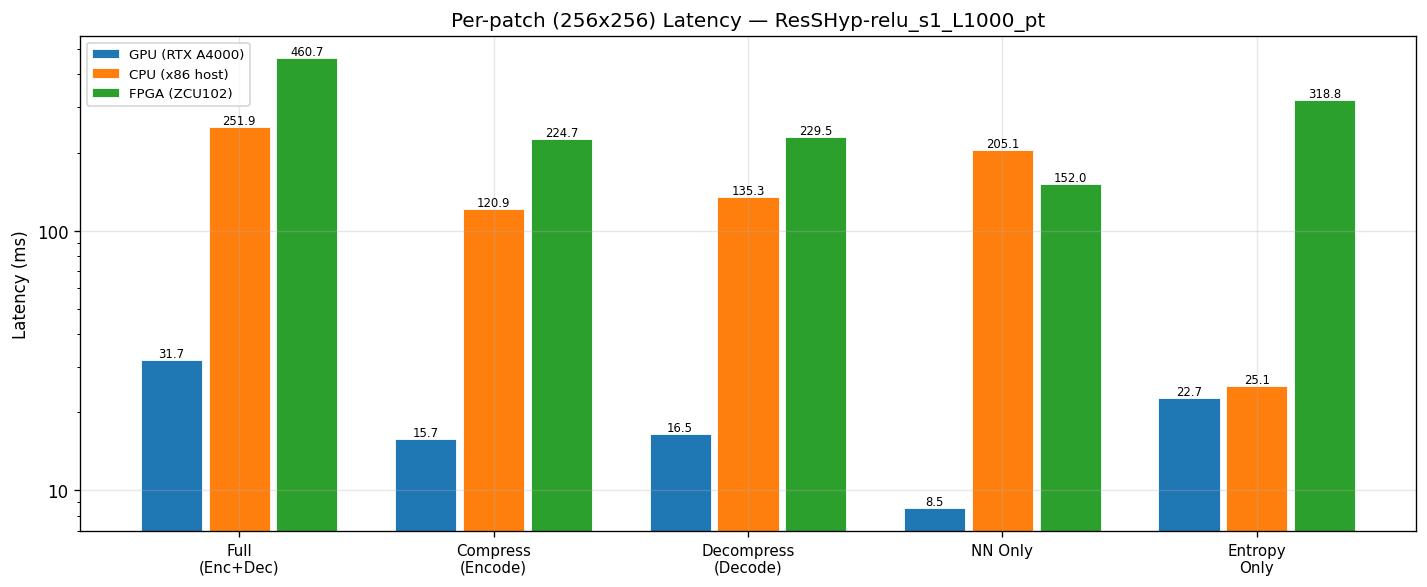

In [42]:
def plot_grouped_bars(
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
    scenarios: Optional[List[str]] = None,
    ax: Optional[Axes] = None,
    log_scale: bool = False,
    bar_label_fmt: str = "{:.1f}",
) -> Axes:
    """Grouped bar chart: one cluster per scenario, one bar per platform."""
    scenarios = scenarios or SCENARIO_ORDER
    platforms = [p for p in PLATFORM_ORDER if p in df["platform"].cat.categories
                 and (df["platform"] == p).any()]

    _own_fig = ax is None
    if _own_fig:
        fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(scenarios))
    width = 0.8 / len(platforms)

    for i, plat in enumerate(platforms):
        vals = []
        for sc in scenarios:
            row = df[(df["platform"] == plat) & (df["scenario"] == sc)]
            vals.append(row[metric].values[0] if len(row) else 0)
        offset = (i - len(platforms) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=PLATFORM_LABELS.get(plat, plat),
                       color=PLATFORM_COLORS.get(plat, "gray"), edgecolor="white", linewidth=0.5)
        # Value labels on bars
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        bar_label_fmt.format(v), ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([SCENARIO_LABELS.get(s, s) for s in scenarios], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    if _own_fig:
        fig.tight_layout()
    return ax


plot_grouped_bars(
    df, "latency_ms", "Latency (ms)", f"Per-patch (256x256) Latency — {MODEL_NAME}",
    log_scale=True,
)
if SAVE_FIGURES:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(PLOTS_DIR / "latency_comparison.png", bbox_inches="tight")
plt.show()

## 5 · Per-Step Latency Breakdown (Stacked Bars)

Shows **where time is spent** within each scenario on each platform.  Steps are grouped
into two categories:

- **NN steps** (`nn_g_a`, `nn_h_a`, `nn_h_s`, `nn_g_s`): model forward passes on the
  accelerator (GPU CUDA cores / FPGA DPU / CPU via PyTorch).
- **CPU steps** (`cpu_eb_compress`, `cpu_eb_decompress`, `cpu_gc_compress`,
  `cpu_gc_decompress`, `cpu_concat_abs`, `cpu_split_y_hat`): entropy coding and data
  manipulation, always on CPU (x86 or ARM A53).

### Interpretation notes

- Step labels have been **canonicalised**: `gpu_g_a` → `nn_g_a`, `dpu_g_a` → `nn_g_a`.
  This allows direct visual comparison of the same logical step across platforms.
- **GC compress/decompress dominates** on all platforms because the Gaussian Conditional
  entropy coder operates on 256-channel, 16x16 tensors (~65K symbols) using sequential
  rANS.  On the ARM A53, this is 10–30x slower than on x86.
- **NN steps on FPGA include Python/VART overhead**: The FPGA NN times include numpy
  INT8 quantisation, VART dispatch, and numpy dequantisation — typically adding 10–20%
  over the raw DPU hardware time (see `xdputil benchmark` comparison in the doc §6.4).
- **`preprocess` / `postprocess`**: near-zero on all platforms (just timer bookkeeping).
  Omitted from the stacked chart if < 0.1 ms.

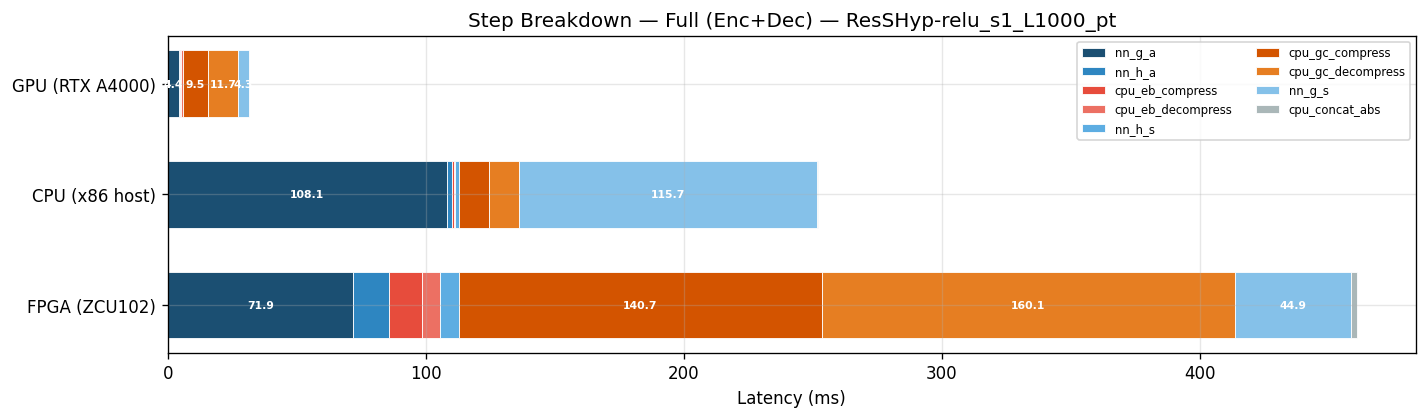

In [43]:
# ── Colour palette for individual steps ────────────────────────────────────────
STEP_COLORS = {
    # NN subgraphs (blue shades)
    "nn_g_a":  "#1b4f72",
    "nn_h_a":  "#2e86c1",
    "nn_h_s":  "#5dade2",
    "nn_g_s":  "#85c1e9",
    # CPU entropy steps (orange/red shades)
    "cpu_eb_compress":   "#e74c3c",
    "cpu_eb_decompress": "#ec7063",
    "cpu_gc_compress":   "#d35400",
    "cpu_gc_decompress": "#e67e22",
    # CPU data ops (grey shades)
    "cpu_concat_abs":    "#aab7b8",
    "cpu_split_y_hat":   "#d5dbdb",
    "preprocess":        "#f0f0f0",
    "postprocess":       "#f0f0f0",
}

# Preferred step order (bottom → top in stacked bar)
STEP_ORDER = [
    "nn_g_a", "nn_h_a", "cpu_eb_compress", "cpu_eb_decompress",
    "nn_h_s", "cpu_gc_compress", "cpu_gc_decompress",
    "cpu_split_y_hat", "nn_g_s",
    "cpu_concat_abs", "preprocess", "postprocess",
]


def plot_step_breakdown(
    df: pd.DataFrame,
    scenario: str,
    ax: Optional[Axes] = None,
    min_ms: float = 0.1,
) -> Axes:
    """Stacked horizontal bar chart for one scenario across all platforms."""
    subset = df[df["scenario"] == scenario].sort_values("platform")
    if subset.empty:
        raise ValueError(f"No data for scenario '{scenario}'")

    _own = ax is None
    if _own:
        fig, ax = plt.subplots(figsize=(12, max(2, len(subset) * 1.2)))

    y_labels = []
    for idx, (_, row) in enumerate(subset.iterrows()):
        plat = str(row["platform"])
        steps: Dict[str, float] = row["_step_breakdown"]
        y_labels.append(PLATFORM_LABELS.get(plat, plat))

        # Order steps, skip tiny ones
        ordered = [(s, steps.get(s, 0)) for s in STEP_ORDER if steps.get(s, 0) >= min_ms]
        # Add any remaining steps not in STEP_ORDER
        known = set(STEP_ORDER)
        for s, v in sorted(steps.items()):
            if s not in known and v >= min_ms and not s.startswith("_"):
                ordered.append((s, v))

        left = 0.0
        for step_name, ms_val in ordered:
            color = STEP_COLORS.get(step_name, "#bdc3c7")
            bar = ax.barh(idx, ms_val, left=left, height=0.6, color=color,
                          edgecolor="white", linewidth=0.5, label=step_name)
            # Label if wide enough
            if ms_val > row["latency_ms"] * 0.05:
                ax.text(left + ms_val / 2, idx, f"{ms_val:.1f}",
                        ha="center", va="center", fontsize=6.5, color="white", fontweight="bold")
            left += ms_val

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Latency (ms)")
    ax.set_title(f"Step Breakdown — {SCENARIO_LABELS.get(scenario, scenario).replace(chr(10), ' ')} — {MODEL_NAME}")
    ax.invert_yaxis()

    # Deduplicated legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=7, ncol=2)

    if _own:
        fig.tight_layout()
    return ax


# Plot the "full" scenario breakdown (the most informative)
plot_step_breakdown(df, "full")
if SAVE_FIGURES:
    plt.savefig(PLOTS_DIR / "step_breakdown_full.png", bbox_inches="tight")
plt.show()

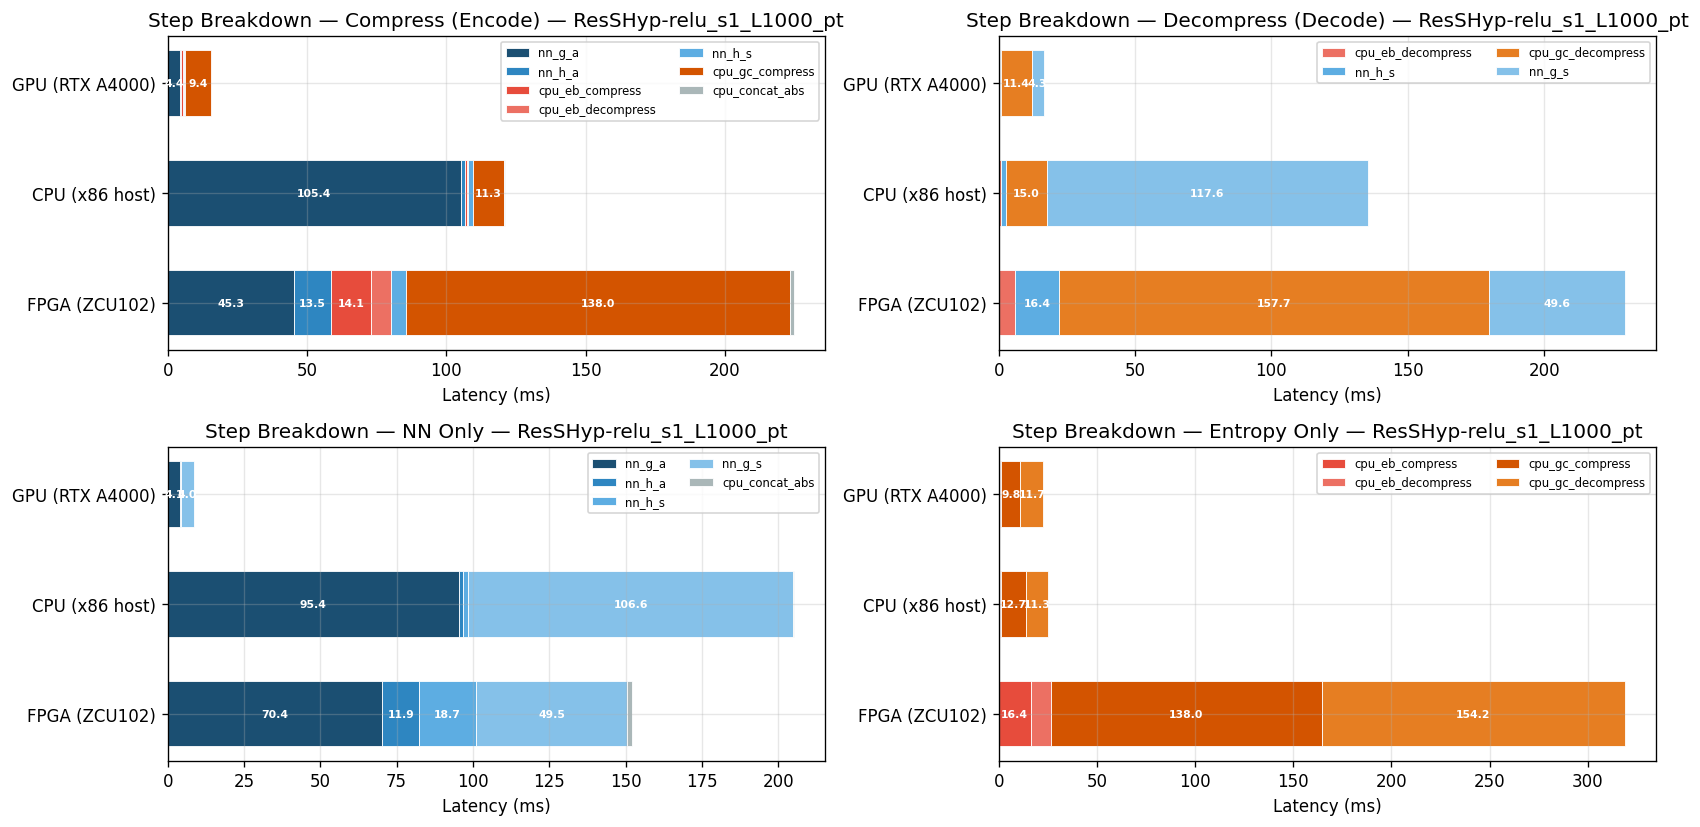

In [44]:
# Breakdown for all other scenarios (compact 2x2 grid)
other_scenarios = [s for s in SCENARIO_ORDER if s != "full" and s in df["scenario"].values]
if other_scenarios:
    n = len(other_scenarios)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]
    for i, sc in enumerate(other_scenarios):
        plot_step_breakdown(df, sc, ax=axes_flat[i])
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / "step_breakdown_all.png", bbox_inches="tight")
    plt.show()

## 6 · NN vs Entropy Latency Split

This chart isolates the **NN accelerator time** from the **CPU entropy time** for each
`(platform, scenario)`.  It directly answers: *"Is the bottleneck in the neural network
or in the entropy coder?"*

### Interpretation notes

- **NN time** = sum of all steps with `gpu_` / `dpu_` / `nn_` prefix.
  On GPU this is the time CUDA kernels spend executing the four subgraphs (g_a, h_a, h_s, g_s).
  On FPGA this is the time the DPU spends + Python/VART overhead.
  On CPU this is PyTorch CPU forward passes.
- **CPU time** = sum of all steps with `cpu_` prefix.
  Entropy coding (EB compress/decompress + GC compress/decompress) + data manipulation
  (concat, abs, split).  This runs on x86 for GPU/CPU benchmarks and on ARM A53 for FPGA.
- **Key insight for deployment**: If CPU time >> NN time, optimising the NN accelerator
  (more DPU cores, higher frequency, GPU upgrade) yields negligible speedup.  Instead,
  the entropy coder must be optimised (faster rANS, hardware entropy coder, or eliminating
  entropy coding from the latency-critical path via pre-computed codebooks).
- **The `nn_only` and `entropy_only` scenarios** should show near-zero in their complementary
  bar — they exist precisely to isolate one component.

**Formulas** (from the JSON output):
$$t_\text{NN} = \sum_{s \in \text{nn\_*}} s.\text{mean\_s} \times 1000 \quad\text{(ms)}$$
$$t_\text{CPU} = \sum_{s \in \text{cpu\_*}} s.\text{mean\_s} \times 1000 \quad\text{(ms)}$$
$$t_\text{total} \approx t_\text{NN} + t_\text{CPU} + t_\text{overhead}$$

where $t_\text{overhead}$ captures pre/postprocess and timer overhead (typically < 0.1 ms).

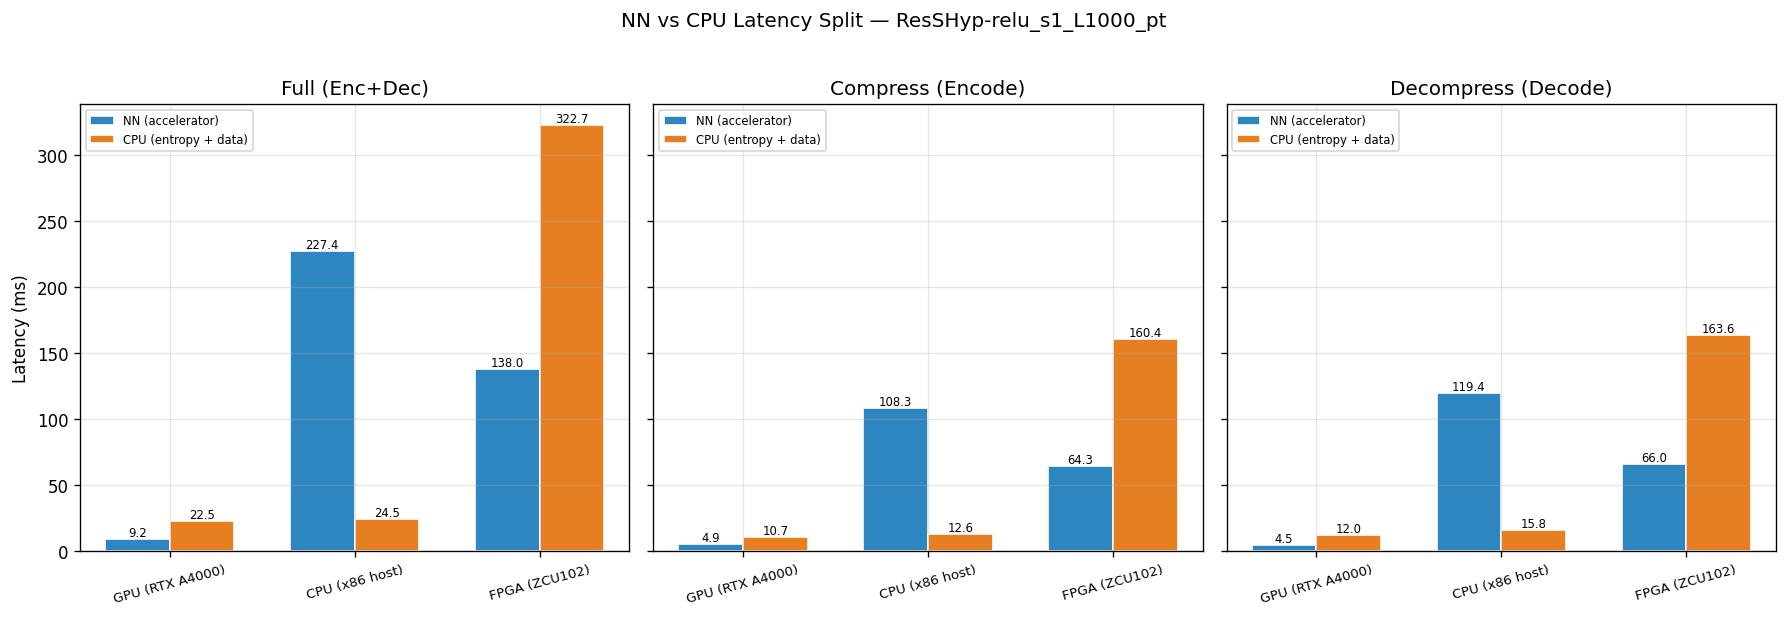

In [45]:
def plot_nn_vs_cpu_split(df: pd.DataFrame, scenarios: Optional[List[str]] = None) -> None:
    """Side-by-side grouped bars showing NN vs CPU time for each platform x scenario."""
    scenarios = scenarios or ["full", "compress", "decompress"]
    fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 5), sharey=True)
    if len(scenarios) == 1:
        axes = [axes]

    for ax, sc in zip(axes, scenarios):
        subset = df[df["scenario"] == sc].sort_values("platform")
        plats = subset["platform"].astype(str).tolist()
        nn_vals = subset["nn_latency_ms"].values
        cpu_vals = subset["cpu_latency_ms"].values

        x = np.arange(len(plats))
        w = 0.35
        bars_nn = ax.bar(x - w / 2, nn_vals, w, label="NN (accelerator)",
                         color="#2e86c1", edgecolor="white")
        bars_cpu = ax.bar(x + w / 2, cpu_vals, w, label="CPU (entropy + data)",
                          color="#e67e22", edgecolor="white")

        for bar, v in zip(bars_nn, nn_vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f"{v:.1f}", ha="center", va="bottom", fontsize=7)
        for bar, v in zip(bars_cpu, cpu_vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f"{v:.1f}", ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels([PLATFORM_LABELS.get(p, p) for p in plats], fontsize=8, rotation=15)
        ax.set_title(SCENARIO_LABELS.get(sc, sc).replace("\n", " "))
        ax.set_ylabel("Latency (ms)" if ax == axes[0] else "")
        ax.legend(fontsize=7, loc="upper left")

    fig.suptitle(f"NN vs CPU Latency Split — {MODEL_NAME}", fontsize=12, y=1.02)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / "nn_vs_cpu_split.png", bbox_inches="tight")
    plt.show()

plot_nn_vs_cpu_split(df)

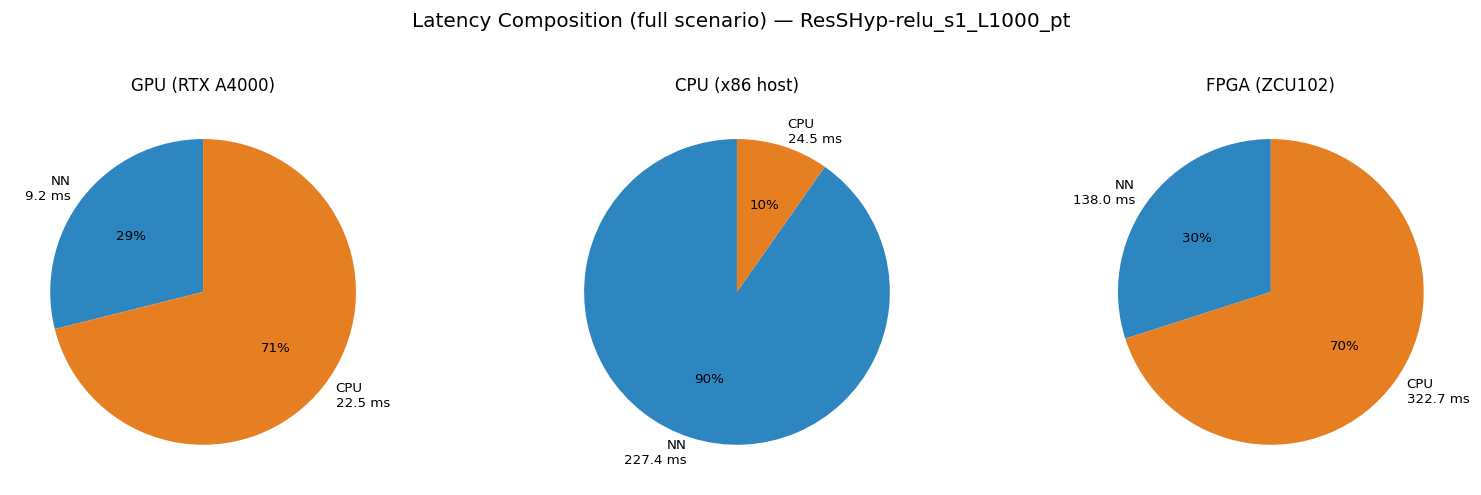

In [46]:
# Pie charts: NN vs CPU fraction for the "full" scenario on each platform
full_df = df[df["scenario"] == "full"].sort_values("platform")
if not full_df.empty:
    fig, axes = plt.subplots(1, len(full_df), figsize=(4.5 * len(full_df), 4))
    if len(full_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, full_df.iterrows()):
        nn = row["nn_latency_ms"]
        cpu = row["cpu_latency_ms"]
        other = max(0, row["latency_ms"] - nn - cpu)
        sizes = [nn, cpu] + ([other] if other > 0.5 else [])
        labels = [f"NN\n{nn:.1f} ms", f"CPU\n{cpu:.1f} ms"]
        colors = ["#2e86c1", "#e67e22"]
        if other > 0.5:
            labels.append(f"Other\n{other:.1f} ms")
            colors.append("#bdc3c7")
        ax.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%",
               startangle=90, textprops={"fontsize": 8})
        ax.set_title(PLATFORM_LABELS.get(str(row["platform"]), str(row["platform"])), fontsize=10)
    fig.suptitle(f"Latency Composition (full scenario) — {MODEL_NAME}", fontsize=12, y=1.02)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / "nn_cpu_pie.png", bbox_inches="tight")
    plt.show()

## 7 · Throughput Comparison

**Throughput** (patches/s) = `n_iters / wall_total_s`, where `wall_total_s` is the
wall-clock time for all measured iterations (excludes warmup).

### Interpretation notes

- Throughput is the **inverse of latency** only if there is no inter-iteration overhead.
  In practice, the Python loop adds a few µs per iteration, so throughput ≈ 1000 / latency_ms.
- **Batch=1 everywhere**: GPU throughput would increase significantly with larger batches
  (the GPU is severely underutilised at batch=1 for this small model).  FPGA DPU B4096
  only supports batch=1.
- **`nn_only` throughput** is the theoretical maximum if entropy coding were instantaneous
  (e.g. via a hardware entropy accelerator or if we don't need entropy coding at all).
- Throughput is useful for **system sizing**: "How many patches per second can this
  platform process?" — e.g. for real-time SAR processing pipelines.

$$\text{Throughput} = \frac{N_\text{iters}}{t_\text{wall}} \;\text{(patches/s)}$$

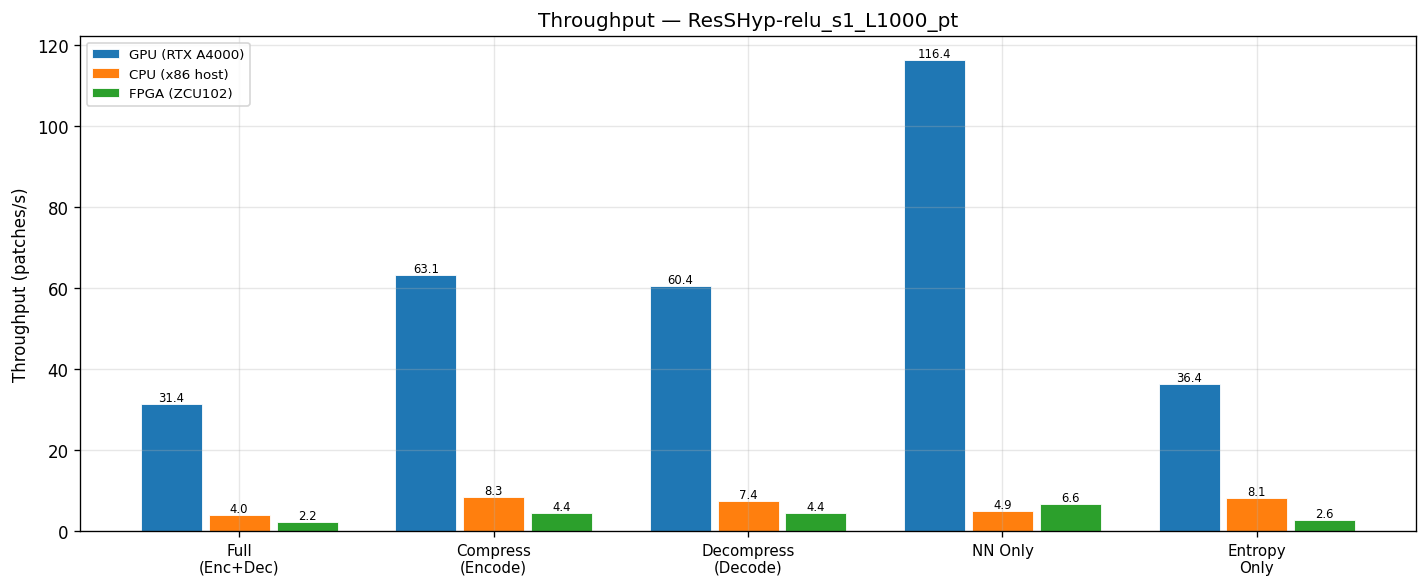

In [47]:
plot_grouped_bars(
    df, "throughput_fps", "Throughput (patches/s)",
    f"Throughput — {MODEL_NAME}",
    log_scale=False,
    bar_label_fmt="{:.1f}",
)
if SAVE_FIGURES:
    plt.savefig(PLOTS_DIR / "throughput_comparison.png", bbox_inches="tight")
plt.show()

## 8 · Power Consumption

### Interpretation notes — **read carefully before citing any power number**

Power measurement is the **most nuanced** metric in this benchmark.  Each platform
uses a fundamentally different measurement technique with different scope:

| Platform | Technique | What is measured | What is NOT measured |
|---|---|---|---|
| **GPU** | `nvidia-smi --query-gpu=power.draw` (polled at 10 Hz) | Total GPU board power (GPU die + VRAM + VRMs) | Host CPU, motherboard, PSU losses, fans, RAM |
| **CPU** (x86) | Intel RAPL `/sys/class/powercap/intel-rapl/` | CPU package (all cores + uncore) + DRAM | Motherboard, PSU, fans, GPU idle draw, NVMe |
| **FPGA** | INA226 sensors on 18 SoC power rails (polled at 50 Hz) | PL fabric (DPU), PS (ARM A53), BRAM, DDR I/O, auxiliary | DDR DRAM cells, SD card, USB, HDMI, barrel jack losses |

**⚠ Key caveats:**
1. **Scopes are not comparable**: GPU power includes things FPGA doesn't (e.g. VRAM), and
   FPGA measures things GPU doesn't (e.g. DDR I/O).  The GPU host also consumes CPU power
   during entropy coding, which is captured by RAPL but not by nvidia-smi alone.
2. **Idle power is significant**: The GPU draws ~15 W idle, the FPGA draws ~6 W on VCCINT
   alone.  Dynamic (incremental) power = load − idle.  The `--idle-baseline` option captures
   idle power automatically.
3. **nvidia-smi temporal resolution**: nvidia-smi reports an internally-averaged power reading
   updated at ~10 Hz.  Short bursts (< 100 ms) may be smoothed out.
4. **RAPL availability**: On kernels ≥ 5.10, RAPL `energy_uj` files require root
   (`-r--------`).  If RAPL data is missing, CPU power shows 0 W.  The benchmark script
   detects this and warns, but old results may contain silent zeros.
5. **INA226 coverage**: The 18 monitored rails are a **lower bound** of total board power
   (see doc §4.7 and §8.1).

**For publication**: Use **energy per inference** (§9) as the fairest comparison metric,
as it normalises for different latencies and is computed as $E = P \times t$ with
matching scope for each platform.

### Dynamic power estimation

$$P_\text{dynamic} = P_\text{load} - P_\text{idle}$$

This subtracts static power (leakage, clock trees, always-on peripherals).  It represents
the **incremental cost** of running one more inference — the most relevant number for
energy-constrained deployments.

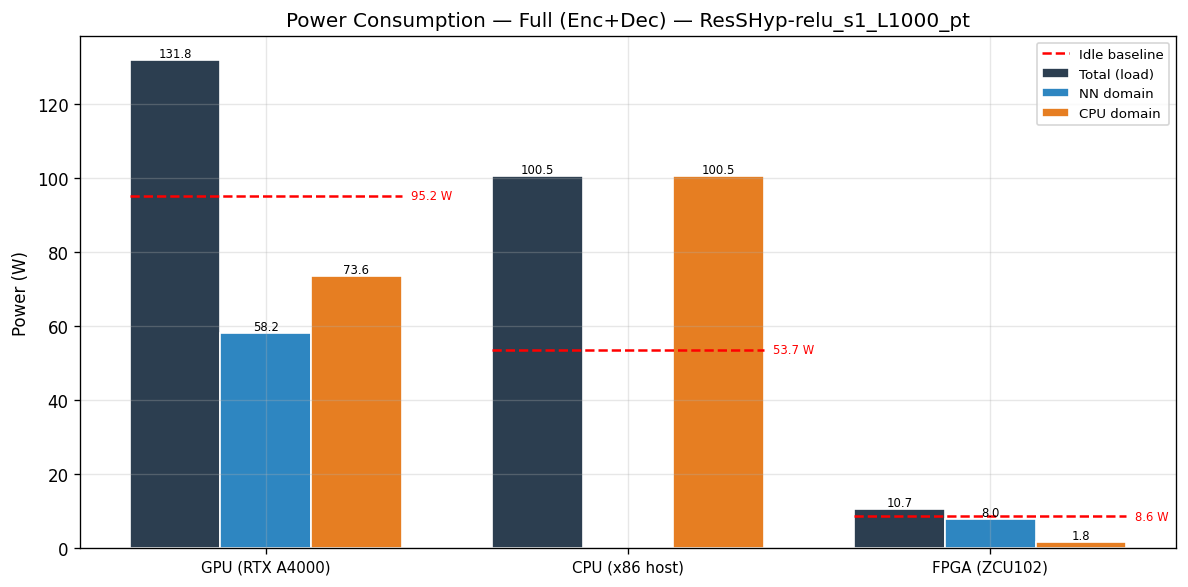

In [48]:
def plot_power(df: pd.DataFrame, scenario: str = "full") -> None:
    """Bar chart of power consumption for one scenario, with idle baseline overlay."""
    subset = df[df["scenario"] == scenario].sort_values("platform")
    subset = subset[subset["power_total_w"].notna()]
    if subset.empty:
        print(f"No power data for scenario '{scenario}'.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    plats = subset["platform"].astype(str).tolist()
    x = np.arange(len(plats))
    w = 0.25

    # Total power
    total_vals = subset["power_total_w"].fillna(0).values
    nn_vals = subset["power_nn_w"].fillna(0).values
    cpu_vals = subset["power_cpu_w"].fillna(0).values
    idle_vals = subset["power_idle_total_w"].fillna(0).values

    ax.bar(x - w, total_vals, w, label="Total (load)", color="#2c3e50", edgecolor="white")
    ax.bar(x, nn_vals, w, label="NN domain", color="#2e86c1", edgecolor="white")
    ax.bar(x + w, cpu_vals, w, label="CPU domain", color="#e67e22", edgecolor="white")

    # Idle baseline as horizontal lines
    if any(idle_vals > 0):
        for xi, idle in zip(x, idle_vals):
            if idle > 0:
                ax.hlines(idle, xi - 1.5 * w, xi + 1.5 * w, colors="red", linestyles="--",
                          linewidth=1.5, label="Idle baseline" if xi == x[0] else "")
                ax.text(xi + 1.6 * w, idle, f"{idle:.1f} W", fontsize=7, color="red", va="center")

    # Value labels
    for xi, t, n, c in zip(x, total_vals, nn_vals, cpu_vals):
        for offset, v in [(-w, t), (0, n), (w, c)]:
            if v > 0:
                ax.text(xi + offset, v, f"{v:.1f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([PLATFORM_LABELS.get(p, p) for p in plats], fontsize=9)
    ax.set_ylabel("Power (W)")
    ax.set_title(f"Power Consumption — {SCENARIO_LABELS.get(scenario, scenario).replace(chr(10), ' ')} — {MODEL_NAME}")

    # Deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / f"power_{scenario}.png", bbox_inches="tight")
    plt.show()

plot_power(df, "full")

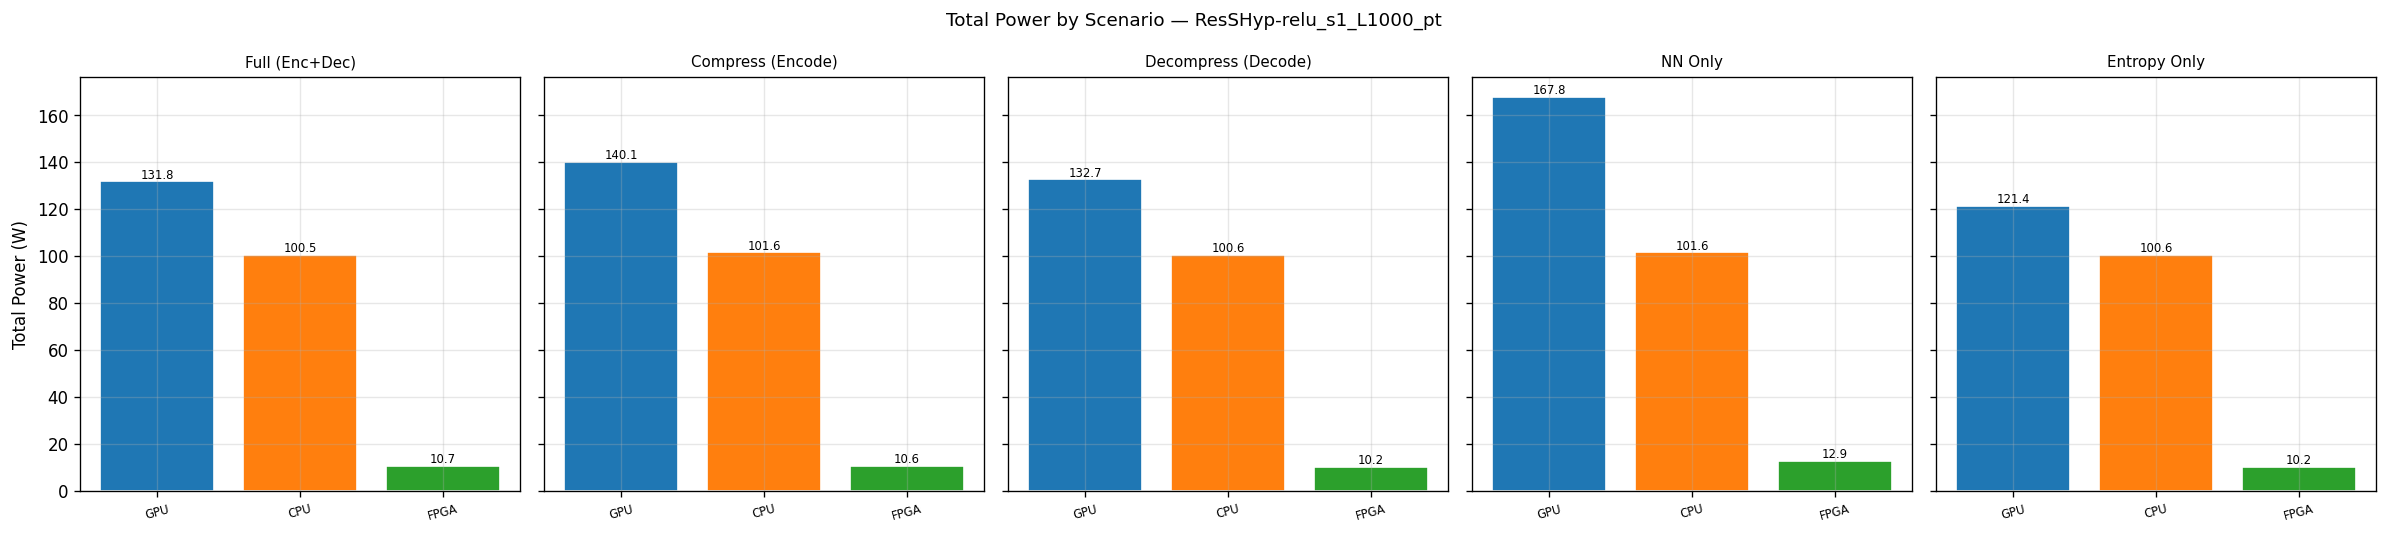

In [49]:
# Power across all scenarios — compact grid
power_scenarios = [s for s in SCENARIO_ORDER
                   if s in df["scenario"].values
                   and df[(df["scenario"] == s) & df["power_total_w"].notna()].shape[0] > 0]
if len(power_scenarios) > 1:
    fig, axes = plt.subplots(1, len(power_scenarios),
                             figsize=(4 * len(power_scenarios), 4.5), sharey=True)
    if len(power_scenarios) == 1:
        axes = [axes]
    for ax, sc in zip(axes, power_scenarios):
        subset = df[(df["scenario"] == sc) & df["power_total_w"].notna()].sort_values("platform")
        plats = subset["platform"].astype(str).tolist()
        x_pos = np.arange(len(plats))
        ax.bar(x_pos, subset["power_total_w"].values,
               color=[PLATFORM_COLORS.get(p, "gray") for p in plats], edgecolor="white")
        for xi, v in zip(x_pos, subset["power_total_w"].values):
            ax.text(xi, v, f"{v:.1f}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([PLATFORM_LABELS.get(p, p).split("(")[0].strip() for p in plats],
                           fontsize=7, rotation=15)
        ax.set_title(SCENARIO_LABELS.get(sc, sc).replace("\n", " "), fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel("Total Power (W)")
    fig.suptitle(f"Total Power by Scenario — {MODEL_NAME}", fontsize=11)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / "power_all_scenarios.png", bbox_inches="tight")
    plt.show()
else:
    print("Not enough power data across scenarios for a grid plot.")

## 9 · Energy per Inference

**Energy per inference** is the single fairest cross-platform comparison metric because
it accounts for both power draw **and** execution time:

$$E_\text{tile} = P_\text{avg} \times t_\text{tile} \quad\text{(Joules)}$$

or equivalently in millijoules:

$$E_\text{tile}\;[\text{mJ}] = P_\text{avg}\;[\text{W}] \times t_\text{tile}\;[\text{ms}]$$

A platform that is fast but power-hungry (GPU) might use more energy per tile than a
platform that is slower but sips power (FPGA).  This is the metric that matters for
battery-powered or energy-constrained deployments (e.g. satellite SAR processing).

### Interpretation notes

1. **Scope mismatch**: $P_\text{avg}$ has different measurement scopes per platform
   (see §8).  For a fully fair comparison, all platforms should include their complete
   system power — which requires an external wall-plug meter.  The numbers here are
   **indicative** but not perfectly apples-to-apples.
2. **Dynamic energy**: To isolate the incremental cost of one inference, compute
   $E_\text{dynamic} = (P_\text{load} - P_\text{idle}) \times t_\text{tile}$.
   This removes static power (idle DPU, idle GPU, clock trees).
3. **Operational context — compress vs decompress**:
   - For a **satellite downlink** scenario, the satellite compresses on-board (FPGA compress)
     and the ground station decompresses (GPU/CPU decompress).  The relevant numbers are
     therefore FPGA-compress energy vs GPU-decompress energy.
   - For **on-ground archival**, both compress and decompress happen on GPU/CPU.

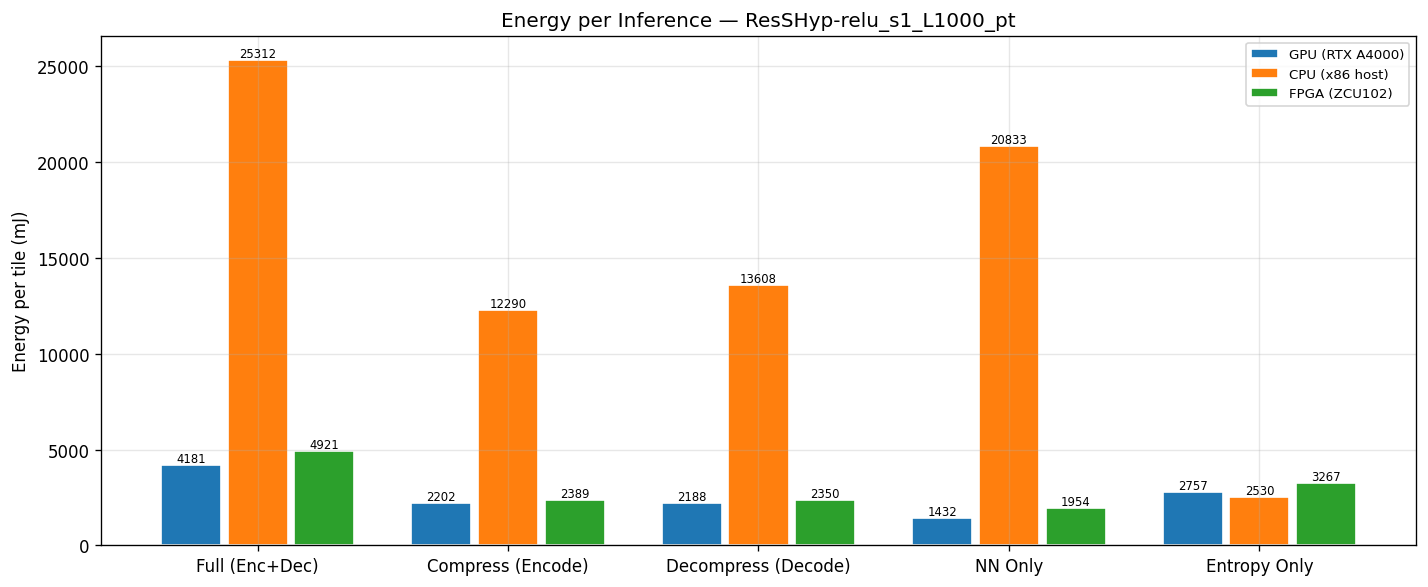


── Dynamic energy (load − idle) ──
  gpu    compress         P_load=140.1 W  P_idle=107.3 W  P_dyn=32.8 W  →  E_dyn=516 mJ
  cpu    compress         P_load=101.6 W  P_idle=64.7 W  P_dyn=36.9 W  →  E_dyn=4465 mJ
  fpga   compress         P_load=10.6 W  P_idle=8.7 W  P_dyn=2.0 W  →  E_dyn=442 mJ
  gpu    decompress       P_load=132.7 W  P_idle=101.7 W  P_dyn=31.1 W  →  E_dyn=512 mJ
  cpu    decompress       P_load=100.6 W  P_idle=59.0 W  P_dyn=41.6 W  →  E_dyn=5627 mJ
  fpga   decompress       P_load=10.2 W  P_idle=8.7 W  P_dyn=1.6 W  →  E_dyn=364 mJ
  gpu    entropy_only     P_load=121.4 W  P_idle=96.0 W  P_dyn=25.4 W  →  E_dyn=576 mJ
  cpu    entropy_only     P_load=100.6 W  P_idle=56.7 W  P_dyn=44.0 W  →  E_dyn=1106 mJ
  fpga   entropy_only     P_load=10.2 W  P_idle=8.7 W  P_dyn=1.6 W  →  E_dyn=497 mJ
  gpu    full             P_load=131.8 W  P_idle=95.2 W  P_dyn=36.6 W  →  E_dyn=1160 mJ
  cpu    full             P_load=100.5 W  P_idle=53.7 W  P_dyn=46.8 W  →  E_dyn=11787 mJ
  fpga  

In [50]:
def plot_energy(df: pd.DataFrame, scenarios: Optional[List[str]] = None) -> None:
    """Bar chart of energy per tile (mJ) across platforms and scenarios."""
    scenarios = scenarios or ["full", "compress", "decompress"]
    edf = df[df["scenario"].isin(scenarios) & df["energy_per_tile_mj"].notna()].copy()
    if edf.empty:
        print("No energy data available (missing power measurements).")
        return

    fig, ax = plt.subplots(figsize=(12, 5))
    platforms = [p for p in PLATFORM_ORDER if p in edf["platform"].cat.categories
                 and (edf["platform"] == p).any()]

    x = np.arange(len(scenarios))
    w = 0.8 / len(platforms)

    for i, plat in enumerate(platforms):
        vals = []
        for sc in scenarios:
            row = edf[(edf["platform"] == plat) & (edf["scenario"] == sc)]
            vals.append(row["energy_per_tile_mj"].values[0] if len(row) else 0)
        offset = (i - len(platforms) / 2 + 0.5) * w
        bars = ax.bar(x + offset, vals, w * 0.9,
                      label=PLATFORM_LABELS.get(plat, plat),
                      color=PLATFORM_COLORS.get(plat, "gray"), edgecolor="white")
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f"{v:.0f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([SCENARIO_LABELS.get(s, s).replace("\n", " ") for s in scenarios])
    ax.set_ylabel("Energy per tile (mJ)")
    ax.set_title(f"Energy per Inference — {MODEL_NAME}")
    ax.legend(fontsize=8)
    fig.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(PLOTS_DIR / "energy_per_tile.png", bbox_inches="tight")
    plt.show()

    # Also show dynamic energy if idle baseline is available
    has_idle = df["power_idle_total_w"].notna().any()
    if has_idle:
        print("\n── Dynamic energy (load − idle) ──")
        for _, row in edf.iterrows():
            idle_w = row.get("power_idle_total_w")
            if idle_w is not None and not pd.isna(idle_w) and idle_w > 0:
                p_dyn = row["power_total_w"] - idle_w
                e_dyn = p_dyn * (row["latency_ms"] / 1000) * 1000  # mJ
                print(f"  {str(row['platform']):5s}  {row['scenario']:15s}  "
                      f"P_load={row['power_total_w']:.1f} W  P_idle={idle_w:.1f} W  "
                      f"P_dyn={p_dyn:.1f} W  →  E_dyn={e_dyn:.0f} mJ")

plot_energy(df, SCENARIO_ORDER)

## 10 · Summary Table for Publication

A single table collecting the key metrics across platforms for the **full** and
**operationally relevant** scenarios (FPGA compress, GPU/CPU decompress).

### Formulas applied

| Metric | Formula | Unit |
|---|---|---|
| Total latency | `latency_total_mean_ms` (direct from JSON) | ms |
| NN latency | `latency_{gpu,dpu,nn}_total_mean_ms` (direct) | ms |
| CPU latency | `latency_cpu_total_mean_ms` (direct) | ms |
| NN fraction | $f_\text{NN} = t_\text{NN} / t_\text{total}$ | % |
| Throughput | `throughput_fps` = `n_iters / wall_total_s` | patches/s |
| BPP | $\text{bpp} = \frac{\text{avg\_compressed\_bytes} \times 8}{256 \times 256}$ | bit/pixel |
| Total power | Platform-specific aggregation (see §8) | W |
| Energy/tile | $E = P_\text{total} \times t_\text{total}$ | mJ |
| Dynamic energy/tile | $E_\text{dyn} = (P_\text{load} - P_\text{idle}) \times t_\text{total}$ | mJ |

In [51]:
def build_summary_table(df: pd.DataFrame, scenario: str = "full") -> pd.DataFrame:
    """Build a publication-ready summary table for one scenario."""
    subset = df[df["scenario"] == scenario].sort_values("platform")

    rows = []
    for _, row in subset.iterrows():
        plat = str(row["platform"])

        # Dynamic power
        p_dyn = None
        e_dyn = None
        idle_w = row.get("power_idle_total_w")
        total_w = row.get("power_total_w")
        if total_w is not None and not pd.isna(total_w) and idle_w is not None and not pd.isna(idle_w):
            p_dyn = total_w - idle_w
            e_dyn = p_dyn * (row["latency_ms"] / 1000) * 1000  # mJ

        rows.append({
            "Platform": PLATFORM_LABELS.get(plat, plat),
            "Precision": "INT8" if plat == "fpga" else "FP32",
            "Total Latency (ms)": round(row["latency_ms"], 2),
            "NN Latency (ms)": round(row["nn_latency_ms"], 2),
            "CPU Latency (ms)": round(row["cpu_latency_ms"], 2),
            "NN Fraction (%)": round(row["nn_fraction"] * 100, 1),
            "Throughput (p/s)": round(row["throughput_fps"], 2),
            "BPP": round(row["bpp"], 4) if row["bpp"] else None,
            "Total Power (W)": round(total_w, 1) if total_w and not pd.isna(total_w) else None,
            "Idle Power (W)": round(idle_w, 1) if idle_w and not pd.isna(idle_w) else None,
            "Energy/tile (mJ)": round(row["energy_per_tile_mj"], 0) if row["energy_per_tile_mj"] and not pd.isna(row["energy_per_tile_mj"]) else None,
            "Dyn. Energy/tile (mJ)": round(e_dyn, 0) if e_dyn else None,
        })

    return pd.DataFrame(rows).set_index("Platform")


# ── Full scenario summary ──────────────────────────────────────────────────────
print("═" * 80)
print(f"  SUMMARY — Full Scenario — {MODEL_NAME}")
print("═" * 80)
summary_full = build_summary_table(df, "full")
display(summary_full)

# ── Operational scenario: FPGA compress + GPU/CPU decompress ───────────────────
print("\n" + "═" * 80)
print(f"  OPERATIONAL COMPARISON — {MODEL_NAME}")
print("  Satellite: FPGA compresses (uplink) → Ground: GPU/CPU decompresses")
print("═" * 80)

operational_rows = []

# FPGA compress
fpga_comp = df[(df["platform"] == "fpga") & (df["scenario"] == "compress")]
if not fpga_comp.empty:
    r = fpga_comp.iloc[0]
    operational_rows.append({
        "Role": "Satellite (compress)",
        "Platform": "FPGA (ZCU102)",
        "Latency (ms)": round(r["latency_ms"], 2),
        "Throughput (p/s)": round(r["throughput_fps"], 2),
        "Power (W)": round(r["power_total_w"], 1) if r["power_total_w"] and not pd.isna(r["power_total_w"]) else None,
        "Energy/tile (mJ)": round(r["energy_per_tile_mj"], 0) if r["energy_per_tile_mj"] and not pd.isna(r["energy_per_tile_mj"]) else None,
    })

# GPU decompress
gpu_decomp = df[(df["platform"] == "gpu") & (df["scenario"] == "decompress")]
if not gpu_decomp.empty:
    r = gpu_decomp.iloc[0]
    operational_rows.append({
        "Role": "Ground (decompress)",
        "Platform": "GPU (RTX A4000)",
        "Latency (ms)": round(r["latency_ms"], 2),
        "Throughput (p/s)": round(r["throughput_fps"], 2),
        "Power (W)": round(r["power_total_w"], 1) if r["power_total_w"] and not pd.isna(r["power_total_w"]) else None,
        "Energy/tile (mJ)": round(r["energy_per_tile_mj"], 0) if r["energy_per_tile_mj"] and not pd.isna(r["energy_per_tile_mj"]) else None,
    })

# CPU decompress
cpu_decomp = df[(df["platform"] == "cpu") & (df["scenario"] == "decompress")]
if not cpu_decomp.empty:
    r = cpu_decomp.iloc[0]
    operational_rows.append({
        "Role": "Ground (decompress)",
        "Platform": "CPU (x86 host)",
        "Latency (ms)": round(r["latency_ms"], 2),
        "Throughput (p/s)": round(r["throughput_fps"], 2),
        "Power (W)": round(r["power_total_w"], 1) if r["power_total_w"] and not pd.isna(r["power_total_w"]) else None,
        "Energy/tile (mJ)": round(r["energy_per_tile_mj"], 0) if r["energy_per_tile_mj"] and not pd.isna(r["energy_per_tile_mj"]) else None,
    })

if operational_rows:
    op_df = pd.DataFrame(operational_rows).set_index("Role")
    display(op_df)

════════════════════════════════════════════════════════════════════════════════
  SUMMARY — Full Scenario — ResSHyp-relu_s1_L1000_pt
════════════════════════════════════════════════════════════════════════════════


,Precision,Total Latency (ms),NN Latency (ms),CPU Latency (ms),NN Fraction (%),Throughput (p/s),BPP,Total Power (W),Idle Power (W),Energy/tile (mJ),Dyn. Energy/tile (mJ)
Platform,,,,,,,,,,,
GPU (RTX A4000),FP32,31.72,9.15,22.51,28.9,31.44,5.3311,131.8,95.2,4181.0,1160.0
CPU (x86 host),FP32,251.95,227.37,24.53,90.2,3.97,5.3149,100.5,53.7,25312.0,11787.0
FPGA (ZCU102),INT8,460.69,137.97,322.71,29.9,2.17,5.5991,10.7,8.6,4921.0,946.0



════════════════════════════════════════════════════════════════════════════════
  OPERATIONAL COMPARISON — ResSHyp-relu_s1_L1000_pt
  Satellite: FPGA compresses (uplink) → Ground: GPU/CPU decompresses
════════════════════════════════════════════════════════════════════════════════


,Platform,Latency (ms),Throughput (p/s),Power (W),Energy/tile (mJ)
Role,,,,,
Satellite (compress),FPGA (ZCU102),224.72,4.45,10.6,2389.0
Ground (decompress),GPU (RTX A4000),16.49,60.43,132.7,2188.0
Ground (decompress),CPU (x86 host),135.27,7.39,100.6,13608.0


In [52]:
# ── Export summaries as CSV ─────────────────────────────────────────────────────
if SAVE_FIGURES:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    summary_full.to_csv(PLOTS_DIR / "summary_full.csv")
    if operational_rows:
        op_df.to_csv(PLOTS_DIR / "summary_operational.csv")
    print(f"Saved CSVs to {PLOTS_DIR}/")
else:
    print("Set SAVE_FIGURES = True to export CSVs and PNGs.")

Set SAVE_FIGURES = True to export CSVs and PNGs.


---
## 11 · FPGA Parallel vs Sequential Comparison

> **Standalone section — independent of the main `df` DataFrame.**
> Sequential result files (`benchmark_fpga_<scenario>_sequential.json`) are loaded
> directly from disk here and are **excluded from all §2–§10 analyses** (overview
> table, latency plots, power charts, summary tables).  Only this section reads them.

All FPGA scenarios use **parallel real‖imag execution by default** via Python threads.
`execute_async` releases the GIL while waiting on hardware, so two threads calling
`runner.run()` simultaneously genuinely overlap on the ZCU102's three DPU cores.

### Confirmed speedup (both g_a and g_s — updated results)

| Stage | Sequential | Parallel (default) | Speedup |
|---|---|---|---|
| `dpu_g_a` | ~74.0 ms | ~39.1 ms | **~1.9×** |
| `dpu_g_s` | ~73.6 ms | ~38.9 ms | **~1.9×** |
| Total DPU | ~151 ms | ~82 ms | **~1.8×** |
| Total | ~406 ms | ~338 ms | **~1.2×** |

> **Bug found & fixed:** `g_s` was not benefiting from parallelism because VART assigns DPU
> cores via **static round-robin** at `Runner.create_runner()` call time.  The old creation
> order `(g_a_1, g_s_1)` caused `g_s_1` to land on the **same** core as `g_s`, giving no
> overlap.  Fix: `for key in ("g_s", "g_a"):` — `g_s_1` is created first, landing on a
> core ≠ g_s (core 1 vs core 2).

### Generating the sequential baseline

`run_full_benchmark.py` now runs **both parallel and sequential** modes by default.  To
skip one:
```bash
python run_full_benchmark.py --no-fpga-sequential   # parallel only (fast)
python run_full_benchmark.py --no-fpga-parallel     # sequential only
```
Sequential files are saved as `benchmark_fpga_<scenario>_sequential.json`.

### Sub-sections

| Cell | Content |
|---|---|
| **§11a** | `full` — complete pipeline, parallel vs sequential |
| **§11b** | `compress` — encode path only |
| **§11d** | 4-way comparison: GPU / CPU / FPGA-parallel / FPGA-sequential |



  Scenario: full
  Mode                                      Total (ms)   DPU (ms)   CPU (ms)
  ──────────────────────────────────────────────────────────────────────────
  full  (parallel ‖)                            460.69     137.97     322.71
  full  (sequential)                            499.28     185.21     314.06

    nn_g_a    :  seq=79.5 ms  par=71.9 ms  saved=7.6 ms (10%)
    nn_g_s    :  seq=82.5 ms  par=44.9 ms  saved=37.5 ms (46%)
    nn_h_a    :  seq=2.4 ms  par=13.8 ms  saved=-11.5 ms (-485%)
    nn_h_s    :  seq=20.9 ms  par=7.3 ms  saved=13.6 ms (65%)
    Total     :  seq=499.3 ms  par=460.7 ms  saved=38.6 ms (8%)


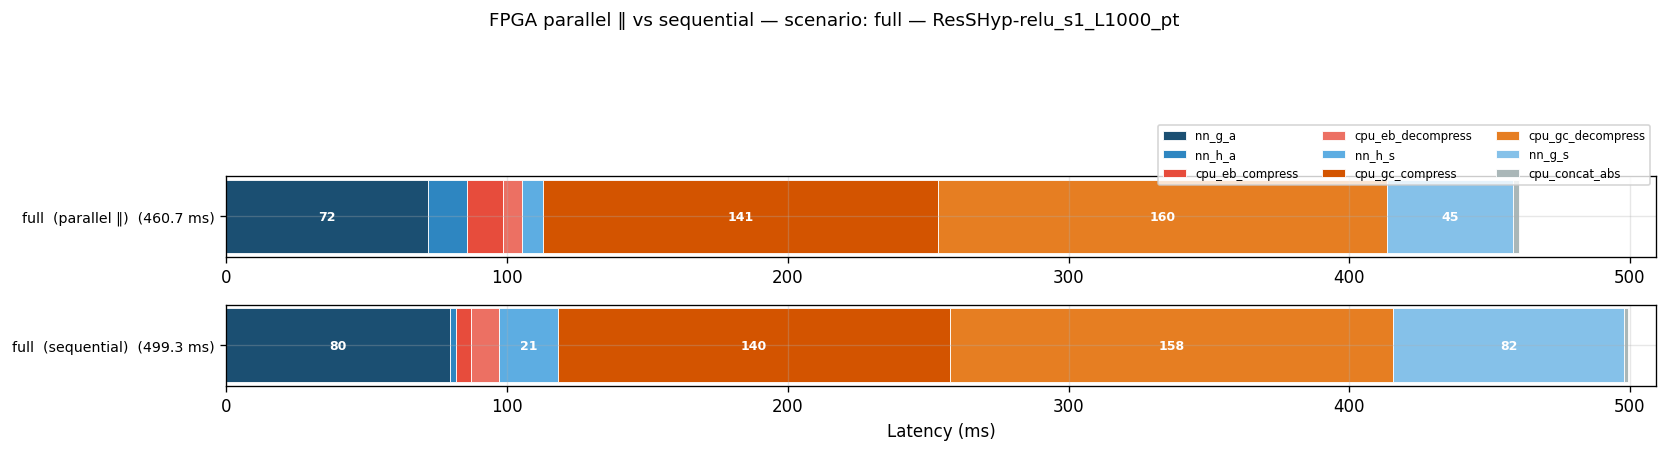

In [53]:
# ──────────────────────────────────────────────────────────────────────────────
# §11 helper: parallel ‖ vs sequential comparison for any FPGA scenario
# ──────────────────────────────────────────────────────────────────────────────

def _load_fpga_scenario(scenario: str) -> Tuple[Optional[dict], Optional[dict]]:
    """Return (parallel_dict, sequential_dict | None) for an FPGA scenario.

    Each dict has keys: label, latency_ms, nn_latency_ms, cpu_latency_ms, steps.
    """
    par_row = df[(df["platform"] == "fpga") & (df["scenario"] == scenario)]

    seq_path = BENCHMARK_DIR / f"benchmark_fpga_{scenario}_sequential.json"
    seq_raw: Optional[dict] = None
    if seq_path.exists():
        with open(seq_path) as _f:
            seq_raw = json.load(_f)

    par_data: Optional[dict] = None
    if not par_row.empty:
        r = par_row.iloc[0]
        par_data = {
            "label": f"{scenario}  (parallel ‖)",
            "latency_ms": float(r["latency_ms"]),
            "nn_latency_ms": float(r["nn_latency_ms"]),
            "cpu_latency_ms": float(r["cpu_latency_ms"]),
            "steps": r["_step_breakdown"],
        }

    seq_data: Optional[dict] = None
    if seq_raw is not None:
        seq_data = {
            "label": f"{scenario}  (sequential)",
            "latency_ms": float(seq_raw.get("latency_total_mean_ms", 0.0)),
            "nn_latency_ms": float(seq_raw.get("latency_dpu_total_mean_ms", 0.0)),
            "cpu_latency_ms": float(seq_raw.get("latency_cpu_total_mean_ms", 0.0)),
            "steps": _extract_step_breakdown(seq_raw, "fpga"),
        }

    return par_data, seq_data


def compare_scenario(scenario: str) -> None:
    """Print summary table and step-breakdown chart for a parallel vs sequential FPGA run."""
    par, seq = _load_fpga_scenario(scenario)

    variants = [v for v in (par, seq) if v is not None]
    if not variants:
        print(f"⚠  No data for scenario '{scenario}'.  Run the benchmark first.")
        return

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n  Scenario: {scenario}")
    print(f"  {'Mode':<40s}  {'Total (ms)':>10s}  {'DPU (ms)':>9s}  {'CPU (ms)':>9s}")
    print("  " + "─" * 74)
    for v in variants:
        print(f"  {v['label']:<40s}  {v['latency_ms']:10.2f}  "
              f"{v['nn_latency_ms']:9.2f}  {v['cpu_latency_ms']:9.2f}")

    if par is not None and seq is not None:
        print()
        for key in ("nn_g_a", "nn_g_s", "nn_h_a", "nn_h_s"):
            v_par = par["steps"].get(key, 0.0)
            v_seq = seq["steps"].get(key, 0.0)
            if v_par > 0.5 or v_seq > 0.5:
                gain = (v_seq - v_par) / v_seq * 100 if v_seq > 0 else 0.0
                print(f"    {key:10s}:  seq={v_seq:.1f} ms  par={v_par:.1f} ms  "
                      f"saved={v_seq - v_par:.1f} ms ({gain:.0f}%)")
        saved = seq["latency_ms"] - par["latency_ms"]
        pct = saved / seq["latency_ms"] * 100 if seq["latency_ms"] > 0 else 0.0
        print(f"    {'Total':10s}:  seq={seq['latency_ms']:.1f} ms  "
              f"par={par['latency_ms']:.1f} ms  saved={saved:.1f} ms ({pct:.0f}%)")

    # ── Step breakdown chart ───────────────────────────────────────────────────
    n = len(variants)
    fig, axes = plt.subplots(n, 1, figsize=(14, 1.4 * n + 1))
    if n == 1:
        axes = [axes]

    max_lat = max(v["latency_ms"] for v in variants)
    for ax, v in zip(axes, variants):
        steps = v["steps"]
        ordered = [(s, steps.get(s, 0.0)) for s in STEP_ORDER if steps.get(s, 0.0) >= 0.1]
        known = {s for s, _ in ordered}
        for s, val in sorted(steps.items()):
            if s not in known and val >= 0.1:
                ordered.append((s, val))

        left = 0.0
        for step_name, ms_val in ordered:
            color = STEP_COLORS.get(step_name, "#bdc3c7")
            ax.barh(0, ms_val, left=left, height=0.55, color=color,
                    edgecolor="white", linewidth=0.5, label=step_name)
            if ms_val > max_lat * 0.04:
                ax.text(left + ms_val / 2, 0, f"{ms_val:.0f}",
                        ha="center", va="center", fontsize=7.5,
                        color="white", fontweight="bold")
            left += ms_val

        ax.set_yticks([0])
        ax.set_yticklabels([f"{v['label']}  ({v['latency_ms']:.1f} ms)"], fontsize=8.5)
        ax.set_xlabel("Latency (ms)" if ax is axes[-1] else "")
        ax.set_xlim(0, max_lat * 1.02)
        if ax is axes[0]:
            handles, lbls = ax.get_legend_handles_labels()
            by_label = dict(zip(lbls, handles))
            ax.legend(by_label.values(), by_label.keys(),
                      loc="upper right", fontsize=7, ncol=3,
                      bbox_to_anchor=(1.0, 1.7))

    fig.suptitle(f"FPGA parallel ‖ vs sequential — scenario: {scenario} — {MODEL_NAME}",
                 fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if SAVE_FIGURES:
        PLOTS_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(PLOTS_DIR / f"fpga_parallel_vs_sequential_{scenario}.png",
                    bbox_inches="tight")
    plt.show()


# ── §11a: full pipeline ────────────────────────────────────────────────────────
compare_scenario("full")


  Scenario: compress
  Mode                                      Total (ms)   DPU (ms)   CPU (ms)
  ──────────────────────────────────────────────────────────────────────────
  compress  (parallel ‖)                        224.72      64.31     160.41
  compress  (sequential)                        261.20     104.82     156.38

    nn_g_a    :  seq=82.9 ms  par=45.3 ms  saved=37.7 ms (45%)
    nn_h_a    :  seq=2.2 ms  par=13.5 ms  saved=-11.4 ms (-526%)
    nn_h_s    :  seq=19.7 ms  par=5.5 ms  saved=14.2 ms (72%)
    Total     :  seq=261.2 ms  par=224.7 ms  saved=36.5 ms (14%)


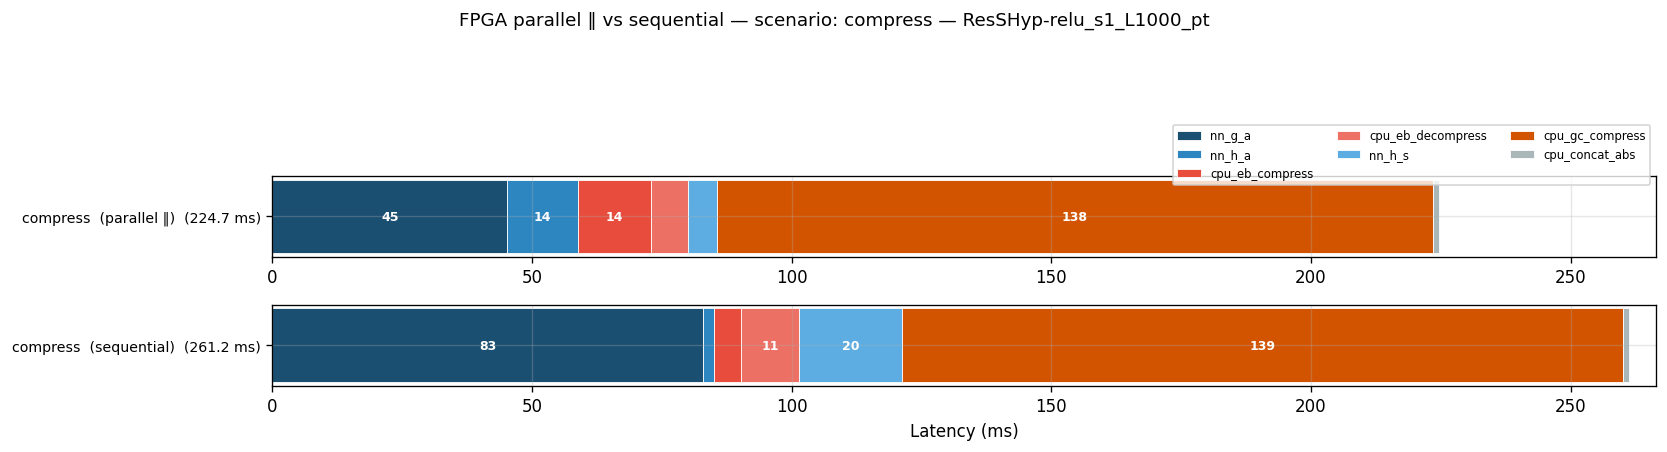

In [54]:
# ── §11b: dpu_only — pure DPU parallelism, no entropy overhead ────────────────
# This scenario exercises only the four DPU subgraphs (g_a, g_s, h_a, h_s)
# without any entropy coding.  The speedup here reflects *only* VART scheduling
# and is not diluted by CPU entropy overhead (~256 ms in the full pipeline).
# Expected: ~2× on nn_g_a and nn_g_s, same as in 'full'.

compare_scenario("compress")

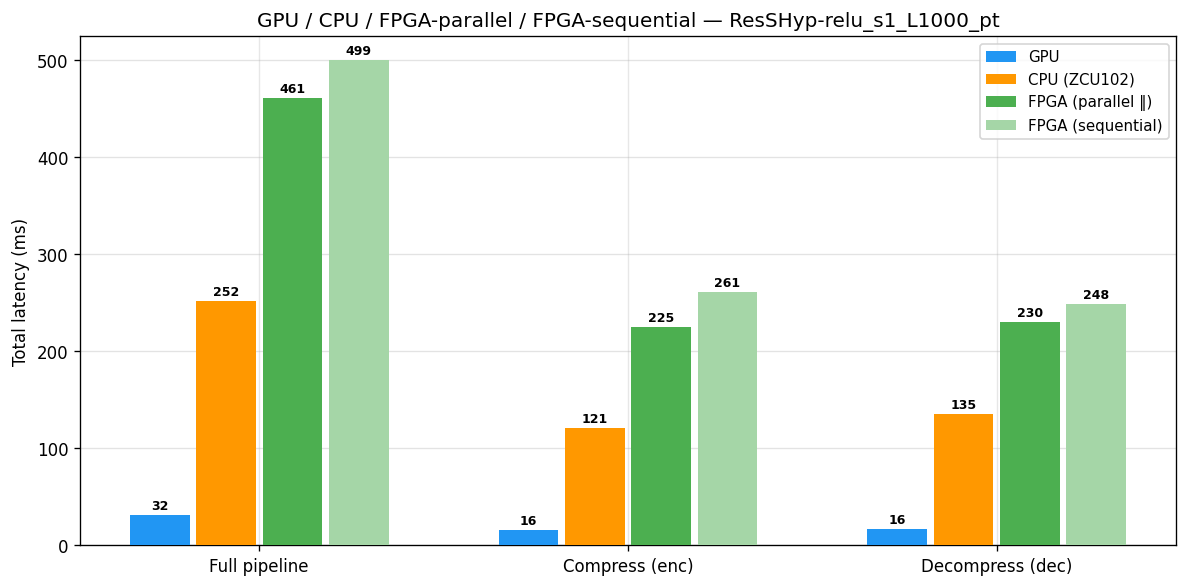

In [55]:
# ── §11d: 4-way latency comparison ────────────────────────────────────────────
# GPU / CPU (ZCU102 ARM) / FPGA-parallel / FPGA-sequential for the three
# cross-platform scenarios: full pipeline, compress-only, decompress-only.

_COMPARE_SC = ["full", "compress", "decompress"]
_COMPARE_LBL = {
    "full": "Full pipeline",
    "compress": "Compress (enc)",
    "decompress": "Decompress (dec)",
}

lat_4way: Dict[str, Dict[str, float]] = {sc: {} for sc in _COMPARE_SC}
for sc in _COMPARE_SC:
    for plat in ("gpu", "cpu", "fpga"):
        row = df[(df["platform"] == plat) & (df["scenario"] == sc)]
        if not row.empty:
            lat_4way[sc][plat] = float(row.iloc[0]["latency_ms"])
    seq_path = BENCHMARK_DIR / f"benchmark_fpga_{sc}_sequential.json"
    if seq_path.exists():
        with open(seq_path) as _f:
            d = json.load(_f)
        lat_4way[sc]["fpga_seq"] = float(d.get("latency_total_mean_ms", 0.0))

platform_info_4way: List[Tuple[str, str, str]] = [
    ("gpu",      "GPU",                "#2196F3"),
    ("cpu",      "CPU (ZCU102)",       "#FF9800"),
    ("fpga",     "FPGA (parallel ‖)",  "#4CAF50"),
    ("fpga_seq", "FPGA (sequential)",  "#A5D6A7"),
]

n_sc = len(_COMPARE_SC)
n_plat = len(platform_info_4way)
x = np.arange(n_sc)
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, (plat, lbl, clr) in enumerate(platform_info_4way):
    vals = [lat_4way[sc].get(plat, float("nan")) for sc in _COMPARE_SC]
    bars = ax.bar(x + (i - n_plat / 2 + 0.5) * width, vals, width=width * 0.9,
                  color=clr, label=lbl, zorder=3)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([_COMPARE_LBL[sc] for sc in _COMPARE_SC], fontsize=10)
ax.set_ylabel("Total latency (ms)")
ax.set_title(f"GPU / CPU / FPGA-parallel / FPGA-sequential — {MODEL_NAME}", fontsize=12)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True, alpha=0.35, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
if SAVE_FIGURES:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(PLOTS_DIR / "fpga_4way_latency_comparison.png", bbox_inches="tight")
plt.show()